In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/RTX-A6000/llama3.2-vision_11b-qwen2.5_7b"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.3570707070707071,
 'total_execution_time': 28579.012766,
 'mean_execution_time': 14.433844831313131,
 'total_tasks': 1980,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 1221,
 'SUCCESS': 707,
 'DB_QUERY_TOOL_ARGS_MISMATCH': 28,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 13,
 'DB_UPDATE_TOOL_ARGS_MISMATCH': 9,
 'OCR_TOOL_RESULT_MISMATCH': 2}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,full_logs,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,DB_QUERY_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-04 01:49:33.861043,2025-04-04 01:52:41.817632,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",187.9566,6,2138,1834,304,0.0,SUCCESS,187.956589,0 days 00:03:07
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-04 01:52:41.826816,2025-04-04 01:52:48.331204,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",6.5044,6,2146,1846,300,0.0,SUCCESS,6.504388,0 days 00:00:06
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,DB_QUERY_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-04 01:52:48.339733,2025-04-04 01:53:53.475172,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",65.1354,112,85940,84479,1461,0.0,SUCCESS,65.135439,0 days 00:01:05
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-04 01:53:53.483540,2025-04-04 01:54:02.773880,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",9.2903,10,3867,3472,395,0.0,SUCCESS,9.290340,0 days 00:00:09
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,DB_QUERY_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-04 01:54:02.782428,2025-04-04 01:54:09.624286,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",6.8419,6,2087,1792,295,0.0,SUCCESS,6.841858,0 days 00:00:06


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

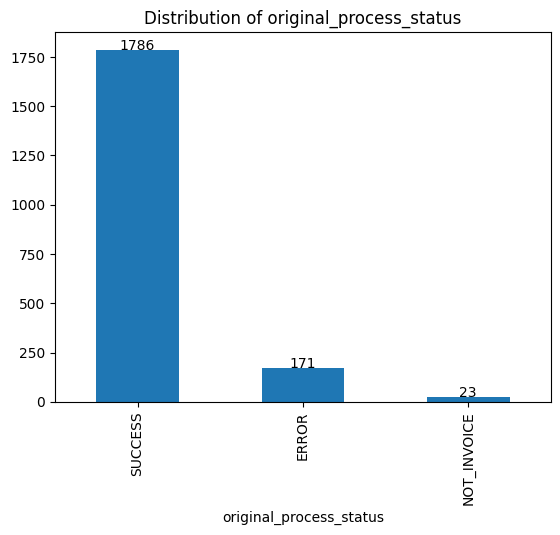

In [7]:
plot_value_distribution(df, "original_process_status")

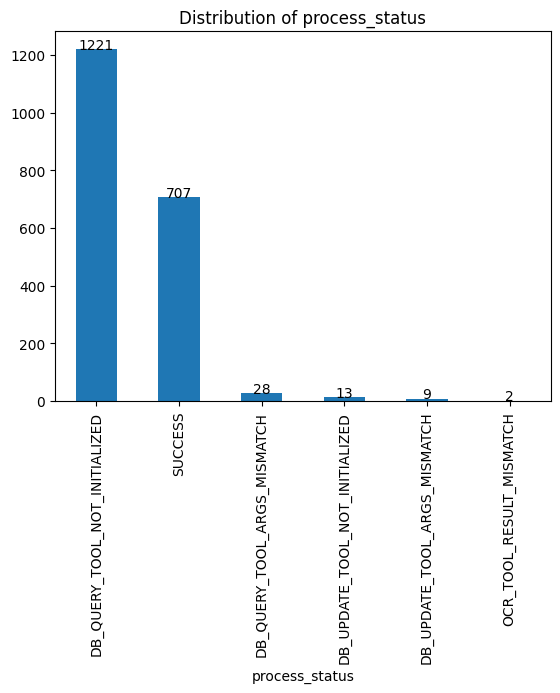

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: DB_QUERY_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-04 01:49:33.861043
--------------------------------------------------
end_time: 2025-04-04 01:52:41.817632
-------------------

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

8

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-04T01:49:33.861043",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-04T01:52:34.208994",


In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\nSent by: Robin Levine\\nYou paid $196 to Tanya\\nTransaction Reference Number: EC4F9FE854344D25\\nTransaction Date: 04/23/23\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 139, \"prompt_tokens\": 90, \"completion_tokens\": 49, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-04T01:52:34.208994",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_update_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"DONE\"}",
    "timestamp": "2025-04-04T01:52:41.805103",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,

2

In [15]:
df["process_status"].value_counts()

process_status
DB_QUERY_TOOL_NOT_INITIALIZED     1221
SUCCESS                            707
DB_QUERY_TOOL_ARGS_MISMATCH         28
DB_UPDATE_TOOL_NOT_INITIALIZED      13
DB_UPDATE_TOOL_ARGS_MISMATCH         9
OCR_TOOL_RESULT_MISMATCH             2
Name: count, dtype: int64

In [16]:
df_filtered = (
    df[df["process_status"] == "OCR_TOOL_RESULT_MISMATCH"].copy().reset_index(drop=True)
)
len(df_filtered)

2

In [17]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: B2E5849991144644B1ADC57FB82FA13B
--------------------------------------------------
sender_email: RobertMoyer@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 77059
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 77059 , Regards Robert Moyer
--------------------------------------------------
attachments: transaction_571.jpeg
--------------------------------------------------
process_status: OCR_TOOL_RESULT_MISMATCH
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-04 05:08:02.712937
--------------------------------------------------
end_time: 2025-04-04 05:08:09.655112
----------------------

In [18]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

8

In [19]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobertMoyer@example.com\n            Subject: Payment Confirmation for Invoice ID: 77059\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 77059 , Regards Robert Moyer\n            Attachment: transaction_571.jpeg\n            \n                ",
    "timestamp": "2025-04-04T05:08:02.712937",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-04T05:08:03.409435"

In [20]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"**Bank Information**\\n* Bank Name: Bank 633\\n* Sent by: Robert Moyer\\n\\n**Transaction Details**\\n* Payment Amount: $44\\n* Recipient: Tanya\\n\\n**Reference Number and Date**\\n* Transaction Reference Number: 9141C93415A246B6\\n* Transaction Date: August 5, 2023\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 162, \"prompt_tokens\": 90, \"completion_tokens\": 72, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-04T05:08:03.409435",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_update_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"DONE\"}",
    

2

In [21]:
logs[-1]

{'name': 'invoice_db_update_tool',
 'type': 'ToolMessage',
 'content': '{"content": "DONE"}',
 'timestamp': '2025-04-04T05:08:09.645313',
 'usage': {'input_tokens': 0,
  'output_tokens': 0,
  'total_tokens': 0,
  'input_token_details': {'audio': 0, 'cache_read': 0},
  'output_token_details': {'audio': 0, 'reasoning': 0}},
 'model_name': '',
 'additional_kwargs': {}}

In [25]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 77059"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [26]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 77059
--------------------------------------------------
bank_name: Bank 633
--------------------------------------------------
transaction_id: 9141C93415A246B6
--------------------------------------------------
amount: 44.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Robert Moyer
--------------------------------------------------
reconciliation_state: PAID
--------------------------------------------------
email_details: Payment Confirmation for Invoice ID: 77059, Hi Tanya ! Please find attached payment screenshot for Invoice ID: 77059, Regards Robert Moyer


In [27]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

247